# Skill Gap Analysis — LinkedIn Job Postings

**Dataset:** LinkedIn Job Postings (real-world, 4,409 tech roles)  
**Models:** Random Forest · SVM (RBF) · BERT  



---
## 1. Installation setup!


In [102]:
#Installing required packages
import subprocess, sys
pkgs = ['pandas','numpy','matplotlib','seaborn','scikit-learn',
        'imbalanced-learn','transformers','torch','pdfplumber','python-docx']
for p in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', p])
print('All packages ready.')


All packages ready.


In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      GridSearchCV, learning_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
from scipy import stats

print('Imports complete.')


Imports complete.


In [104]:
SEEDS   = [42, 123, 456, 789, 1024]
SEED    = SEEDS[0]
CLASSES = ['Low', 'Medium', 'High']
np.random.seed(SEED)
print('Seeds:', SEEDS)


Seeds: [42, 123, 456, 789, 1024]


---
## 2. Data Loading 


In [105]:
df_raw = pd.read_csv('postings.csv', low_memory=False)
print('Raw shape:', df_raw.shape)
print('Columns:', list(df_raw.columns))


Raw shape: (123849, 31)
Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


In [106]:
TECH_TITLES = [
    'data scientist','data analyst','machine learning','ml engineer',
    'software engineer','software developer','data engineer',
    'ai engineer','cloud engineer','devops','cloud architect',
    'cybersecurity','security analyst','business analyst',
    'backend developer','frontend developer','full stack',
    'python developer','nlp engineer','computer vision','deep learning'
]

mask = df_raw['title'].str.lower().apply(
    lambda x: any(t in str(x) for t in TECH_TITLES)
)
df = df_raw[mask].copy().reset_index(drop=True)
print(f'Tech postings: {len(df)}')
print()
print('Experience Level Distribution:')
print(df['formatted_experience_level'].value_counts())


Tech postings: 4416

Experience Level Distribution:
formatted_experience_level
Mid-Senior level    2151
Entry level          584
Associate            264
Director              41
Internship            36
Executive             11
Name: count, dtype: int64


In [107]:
print('Missing values in key columns:')
for c in ['title','description','formatted_experience_level',
          'normalized_salary','remote_allowed']:
    pct = df[c].isna().mean() * 100
    print(f'  {c:<35} {pct:.1f}% missing')


Missing values in key columns:
  title                               0.0% missing
  description                         0.0% missing
  formatted_experience_level          30.1% missing
  normalized_salary                   69.5% missing
  remote_allowed                      69.6% missing


---
## 3. Exploratory Data Analysis (EDA)


In [108]:
def map_category(title):
    t = str(title).lower()
    if any(x in t for x in ['data scientist','machine learning','ml engineer',
                             'nlp engineer','deep learning','ai engineer','computer vision']):
        return 'Data Scientist / ML'
    elif any(x in t for x in ['software engineer','software developer',
                               'backend','frontend','full stack','python developer']):
        return 'Software Developer'
    elif 'data analyst' in t:
        return 'Data Analyst'
    elif 'data engineer' in t:
        return 'Data Engineer'
    elif any(x in t for x in ['cloud','devops']):
        return 'Cloud / DevOps'
    elif any(x in t for x in ['cybersecurity','security analyst']):
        return 'Cybersecurity'
    elif 'business analyst' in t:
        return 'Business Analyst'
    else:
        return 'Other Tech'

df['job_category'] = df['title'].apply(map_category)
print('Job Categories:')
print(df['job_category'].value_counts())


Job Categories:
job_category
Software Developer     1991
Business Analyst        549
Data Scientist / ML     441
Cloud / DevOps          415
Data Analyst            407
Data Engineer           394
Cybersecurity           219
Name: count, dtype: int64


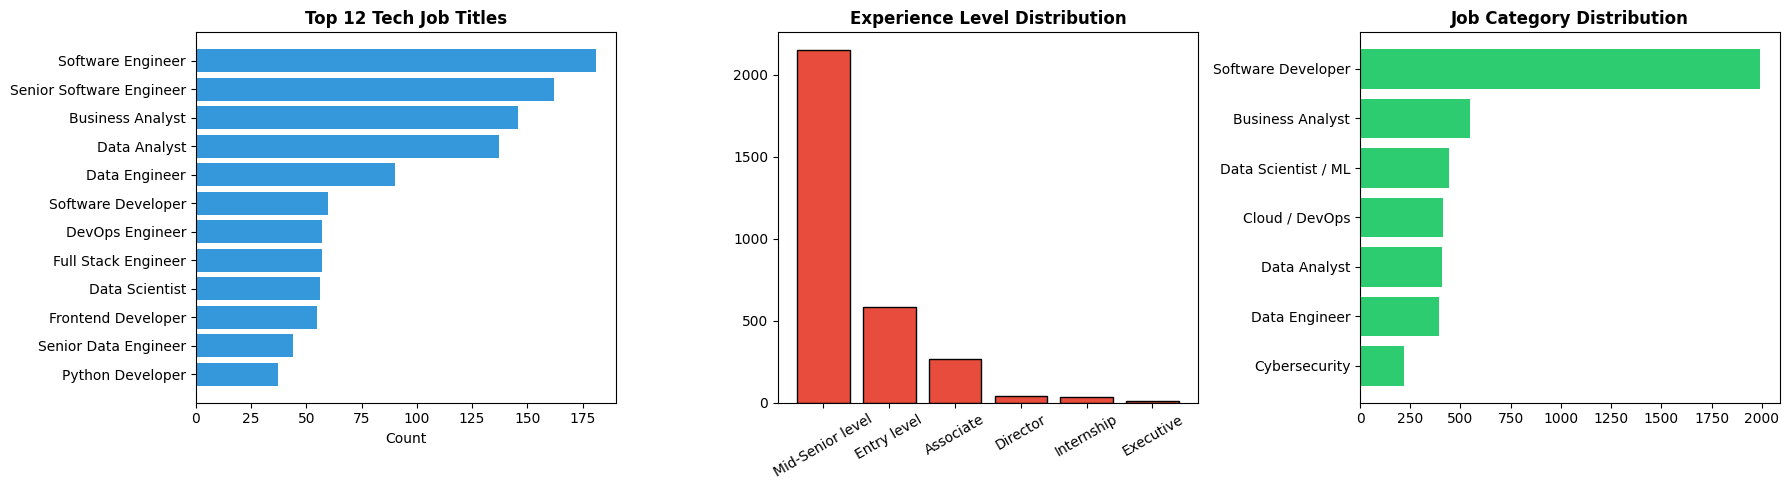

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 12 titles
top_titles = df['title'].value_counts().head(12)
axes[0].barh(top_titles.index[::-1], top_titles.values[::-1], color='#3498DB')
axes[0].set_title('Top 12 Tech Job Titles', fontweight='bold')
axes[0].set_xlabel('Count')

# Experience level
exp_c = df['formatted_experience_level'].value_counts()
axes[1].bar(exp_c.index, exp_c.values, color='#E74C3C', edgecolor='black')
axes[1].set_title('Experience Level Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

# Job category
cat_c = df['job_category'].value_counts()
axes[2].barh(cat_c.index[::-1], cat_c.values[::-1], color='#2ECC71')
axes[2].set_title('Job Category Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


Salary available for 1348 postings (30.5%)


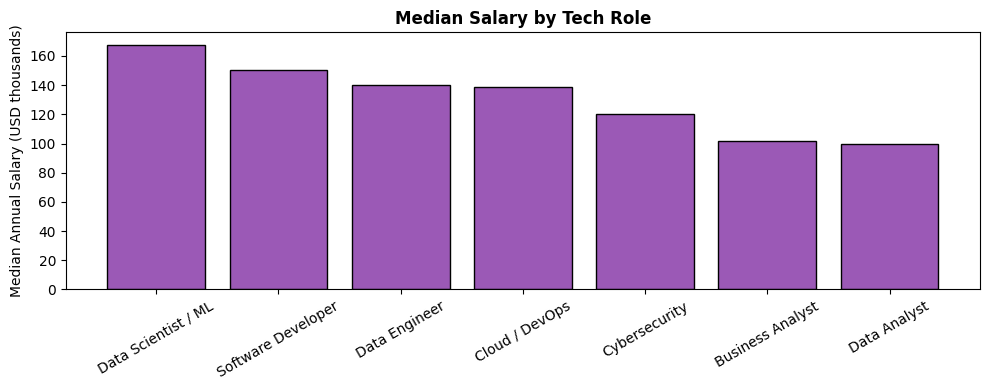

In [110]:
# Salary distribution by category
salary_df = df[df['normalized_salary'].notna()].copy()
print(f'Salary available for {len(salary_df)} postings ({len(salary_df)/len(df)*100:.1f}%)')

if len(salary_df) > 50:
    fig, ax = plt.subplots(figsize=(10, 4))
    sal = salary_df.groupby('job_category')['normalized_salary'].median().sort_values(ascending=False)
    ax.bar(sal.index, sal.values / 1000, color='#9B59B6', edgecolor='black')
    ax.set_ylabel('Median Annual Salary (USD thousands)')
    ax.set_title('Median Salary by Tech Role', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('eda_salary.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## 4. Feature Engineering & Target Variable


Skills are extracted via keyword matching against a curated taxonomy applied to each job description.


In [111]:
# Skills taxonomy
TECH_SKILLS = [
    'machine learning','sql','data analysis','cloud computing',
    'deep learning','natural language processing','computer vision',
    'data engineering','devops','data visualization','statistical analysis',
    'feature engineering','model deployment','api development',
    'cybersecurity','networking','mlops','data pipelines','etl',
]

PROG_LANGS = [
    'python','java','javascript','r','c++','c#','go','scala',
    'kotlin','swift','typescript','matlab','bash','ruby','rust','php',
]

SOFT_SKILLS = [
    'leadership','communication','teamwork','adaptability',
    'time management','critical thinking','creativity','collaboration',
    'presentation','negotiation','project management','analytical thinking',
    'attention to detail','problem solving',
]

TOOLS_KW = [
    'tensorflow','pytorch','scikit-learn','pandas','numpy','tableau',
    'power bi','excel','spark','hadoop','docker','kubernetes',
    'aws','azure','gcp','git','flask','django','fastapi',
    'mysql','postgresql','mongodb','kafka','airflow','snowflake','databricks',
]

def has_word(word, text):
    return bool(re.search(r'\b' + re.escape(word) + r'\b', text))

def extract_skills(text):
    t = str(text).lower()
    tech  = [s for s in TECH_SKILLS  if s in t]
    prog  = [p for p in PROG_LANGS   if has_word(p, t)]
    soft  = [s for s in SOFT_SKILLS  if s in t]
    tools = [tk for tk in TOOLS_KW   if tk in t]
    return tech, prog, soft, tools

print('Taxonomy loaded. Extracting skills from descriptions...')


Taxonomy loaded. Extracting skills from descriptions...


Skill extraction complete.
  Avg tech skills   : 1.42
  Avg prog languages: 1.26
  Avg soft skills   : 1.30
  Avg total skills  : 3.98


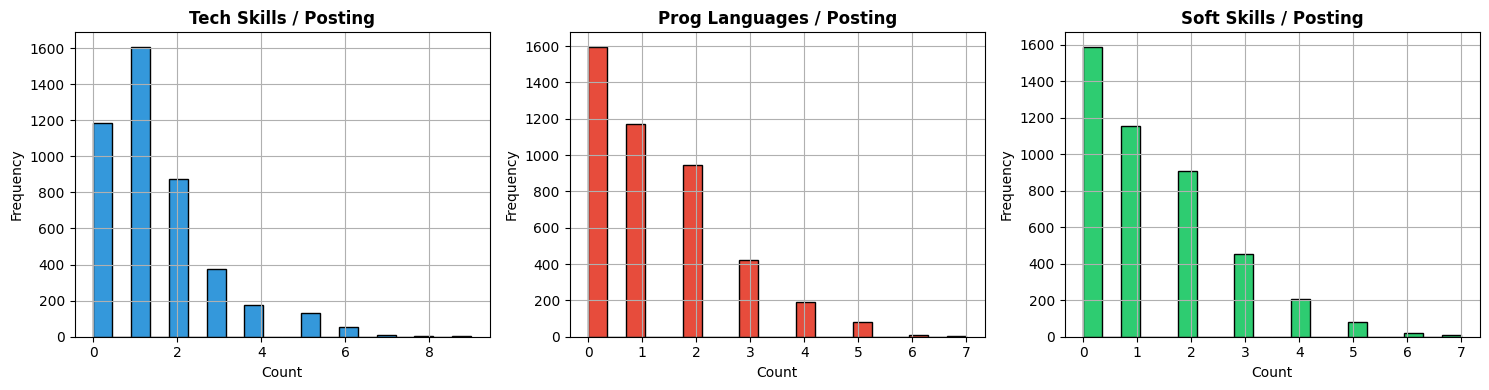

In [112]:
extracted = df['description'].apply(extract_skills)
df['tech_skills']  = extracted.apply(lambda x: x[0])
df['prog_langs']   = extracted.apply(lambda x: x[1])
df['soft_skills']  = extracted.apply(lambda x: x[2])
df['tools']        = extracted.apply(lambda x: x[3])

df['tech_count']   = df['tech_skills'].apply(len)
df['prog_count']   = df['prog_langs'].apply(len)
df['soft_count']   = df['soft_skills'].apply(len)
df['tools_count']  = df['tools'].apply(len)
df['total_skills'] = df['tech_count'] + df['prog_count'] + df['soft_count']

print(f'Skill extraction complete.')
print(f'  Avg tech skills   : {df["tech_count"].mean():.2f}')
print(f'  Avg prog languages: {df["prog_count"].mean():.2f}')
print(f'  Avg soft skills   : {df["soft_count"].mean():.2f}')
print(f'  Avg total skills  : {df["total_skills"].mean():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, color in zip(
        axes,
        ['tech_count', 'prog_count', 'soft_count'],
        ['Tech Skills / Posting', 'Prog Languages / Posting', 'Soft Skills / Posting'],
        ['#3498DB', '#E74C3C', '#2ECC71']
):
    df[col].hist(bins=20, ax=ax, color=color, edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count'); ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('skill_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Target Variable Engineering — Skill Gap Severity




Skill count thresholds per category:
                     q33  q66
job_category                 
Business Analyst     2.0  3.0
Cloud / DevOps       2.0  4.0
Cybersecurity        2.0  4.0
Data Analyst         2.0  4.0
Data Engineer        4.0  6.0
Data Scientist / ML  5.0  7.0
Software Developer   3.0  5.0

Class distribution:
skill_gap_severity
Low       1988
Medium    1279
High      1149
Name: count, dtype: int64


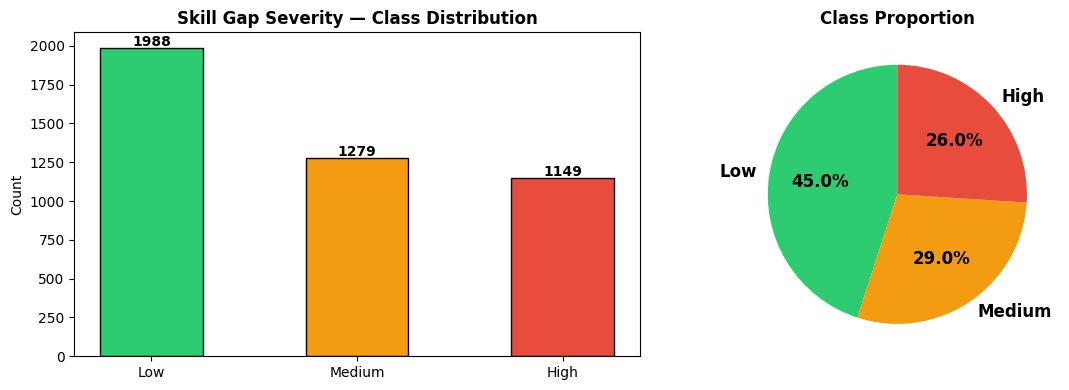

In [113]:
# Compute per-category tertile thresholds
thresholds = df.groupby('job_category')['total_skills'].quantile([0.33, 0.66]).unstack()
thresholds.columns = ['q33', 'q66']
print('Skill count thresholds per category:')
print(thresholds.to_string())

global_q33 = df['total_skills'].quantile(0.33)
global_q66 = df['total_skills'].quantile(0.66)

def assign_severity(row):
    cat = row['job_category']
    cnt = row['total_skills']
    q33 = thresholds.loc[cat, 'q33'] if cat in thresholds.index else global_q33
    q66 = thresholds.loc[cat, 'q66'] if cat in thresholds.index else global_q66
    if cnt <= q33:   return 'Low'
    elif cnt <= q66: return 'Medium'
    else:            return 'High'

df['skill_gap_severity'] = df.apply(assign_severity, axis=1)

print('\nClass distribution:')
print(df['skill_gap_severity'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['skill_gap_severity'].value_counts()[['Low','Medium','High']]
colors = ['#2ECC71','#F39C12','#E74C3C']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')
axes[0].set_title('Skill Gap Severity — Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':12,'fontweight':'bold'})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Feature Matrix Construction


In [114]:
# Experience level encoding
EXP_MAP = {'Internship':0,'Entry level':1,'Associate':2,
           'Mid-Senior level':3,'Director':4,'Executive':5}
df['exp_encoded'] = df['formatted_experience_level'].map(EXP_MAP).fillna(1).astype(int)

# Job category encoding
le_cat = LabelEncoder()
df['cat_encoded'] = le_cat.fit_transform(df['job_category'])

# Multi-label binarisation: tech skills
mlb_tech = MultiLabelBinarizer()
tech_bin  = mlb_tech.fit_transform(df['tech_skills'])
tech_df   = pd.DataFrame(tech_bin,
                columns=['tech_' + s.replace(' ','_') for s in mlb_tech.classes_])

# Multi-label binarisation: programming languages
mlb_prog = MultiLabelBinarizer()
prog_bin  = mlb_prog.fit_transform(df['prog_langs'])
prog_df   = pd.DataFrame(prog_bin,
                columns=['lang_' + p for p in mlb_prog.classes_])

# Multi-label binarisation: soft skills
mlb_soft = MultiLabelBinarizer()
soft_bin  = mlb_soft.fit_transform(df['soft_skills'])
soft_df   = pd.DataFrame(soft_bin,
                columns=['soft_' + s.replace(' ','_').replace('.','') for s in mlb_soft.classes_])

# Numeric features
df['salary_filled'] = df['normalized_salary'].fillna(df['normalized_salary'].median())
df['is_remote']     = df['remote_allowed'].fillna(0).astype(int)

# Combine all features
base = df[['cat_encoded','exp_encoded','tech_count','prog_count',
           'soft_count','tools_count','total_skills',
           'salary_filled','is_remote']].reset_index(drop=True)

X = pd.concat([base,
               tech_df.reset_index(drop=True),
               prog_df.reset_index(drop=True),
               soft_df.reset_index(drop=True)], axis=1)

# Encode target
le_y = LabelEncoder()
le_y.fit(['Low','Medium','High'])
y = le_y.transform(df['skill_gap_severity'])

print(f'Feature matrix : {X.shape[0]} rows x {X.shape[1]} features')
print(f'Classes        : {list(le_y.classes_)}')
print(f'Class mapping  : {dict(zip(le_y.classes_, le_y.transform(le_y.classes_)))}')


Feature matrix : 4416 rows x 58 features
Classes        : [np.str_('High'), np.str_('Low'), np.str_('Medium')]
Class mapping  : {np.str_('High'): np.int64(0), np.str_('Low'): np.int64(1), np.str_('Medium'): np.int64(2)}


---
## 5. Train / Validation / Test Split + SMOTE

Split: **70% train | 15% validation | 15% test** (stratified)  



In [115]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.15/0.85, random_state=SEED, stratify=y_train_val)

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print()
print('Train class distribution (before SMOTE):')
for cls, cnt in zip(le_y.classes_, np.bincount(y_train)):
    print(f'  {cls}: {cnt}')


Train : 3090 samples
Val   : 663 samples
Test  : 663 samples

Train class distribution (before SMOTE):
  High: 804
  Low: 1391
  Medium: 895


In [116]:
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE — training class distribution:')
for cls, cnt in zip(le_y.classes_, np.bincount(y_train_sm)):
    print(f'  {cls}: {cnt}')
print(f'Total training samples: {len(y_train_sm)}')


After SMOTE — training class distribution:
  High: 1391
  Low: 1391
  Medium: 1391
Total training samples: 4173


In [117]:
def evaluate(model, Xt, yt, label='Test'):
    preds = model.predict(Xt)
    f1    = f1_score(yt, preds, average='macro')
    y_bin = label_binarize(yt, classes=[0,1,2])
    try:
        proba = model.predict_proba(Xt)
        auc   = roc_auc_score(y_bin, proba, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')

    print(f'\n{label} Results')
    print(f'  Macro F1 : {f1:.4f}  |  AUC-ROC : {auc:.4f}')
    print()
    print(classification_report(yt, preds, target_names=le_y.classes_))

    cm = confusion_matrix(yt, preds)
    fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_y.classes_, yticklabels=le_y.classes_, ax=ax)
    ax.set_title(f'Confusion Matrix — {label}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()
    return f1, auc

print('evaluate() ready.')


evaluate() ready.


---
## 6. Model 1 — Random Forest



In [118]:
rf_param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [None, 10, 20],
    'min_samples_leaf': [1, 2],
}

rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1_macro', n_jobs=-1, verbose=1,
)
rf_cv.fit(X_train_sm, y_train_sm)

print('Best RF params:', rf_cv.best_params_)
print(f'Best CV F1    : {rf_cv.best_score_:.4f}')


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV F1    : 0.9644



RF — Validation Results
  Macro F1 : 0.9482  |  AUC-ROC : 0.9958

              precision    recall  f1-score   support

        High       0.93      0.97      0.95       172
         Low       0.99      0.97      0.98       299
      Medium       0.92      0.92      0.92       192

    accuracy                           0.95       663
   macro avg       0.95      0.95      0.95       663
weighted avg       0.95      0.95      0.95       663



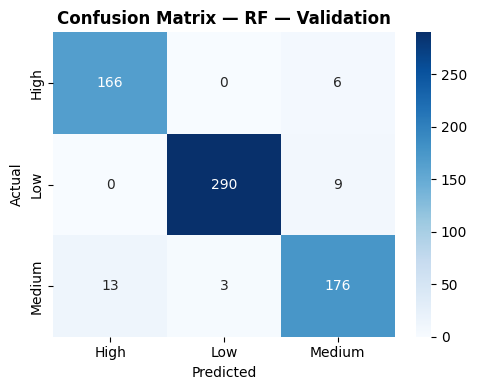


RF — Test Results
  Macro F1 : 0.9533  |  AUC-ROC : 0.9962

              precision    recall  f1-score   support

        High       0.90      0.99      0.94       173
         Low       1.00      0.96      0.98       298
      Medium       0.95      0.92      0.93       192

    accuracy                           0.96       663
   macro avg       0.95      0.96      0.95       663
weighted avg       0.96      0.96      0.96       663



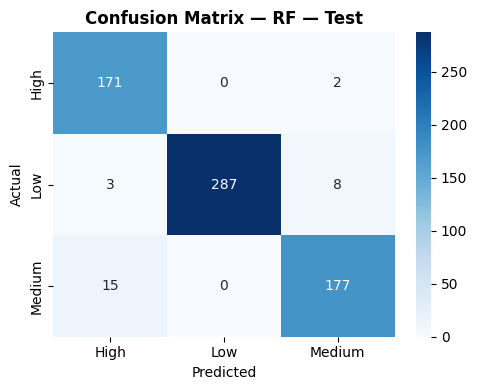

In [119]:
rf_best = rf_cv.best_estimator_
rf_val_f1,  rf_val_auc  = evaluate(rf_best, X_val,  y_val,  'RF — Validation')
rf_test_f1, rf_test_auc = evaluate(rf_best, X_test, y_test, 'RF — Test')


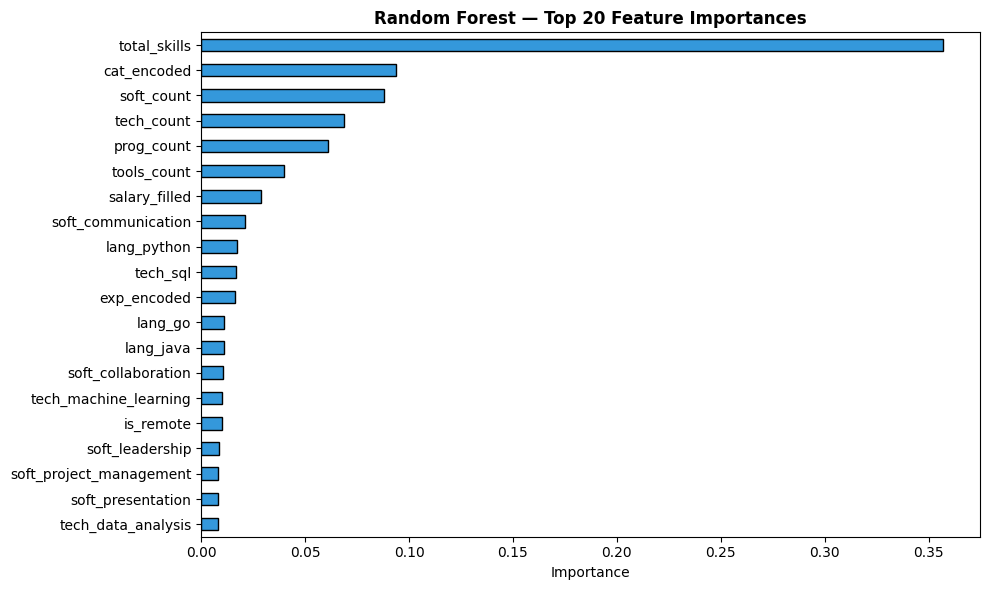

In [120]:
importances = pd.Series(rf_best.feature_importances_, index=X.columns)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20[::-1].plot(kind='barh', color='#3498DB', ax=ax, edgecolor='black')
ax.set_title('Random Forest — Top 20 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [121]:
rf_f1_scores = []
for seed in SEEDS:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.15,
                                           random_state=seed, stratify=y)
    Xtr, _, ytr, _     = train_test_split(Xtr, ytr, test_size=0.15/0.85,
                                           random_state=seed, stratify=ytr)
    sm = SMOTE(random_state=seed)
    Xtr_sm, ytr_sm = sm.fit_resample(Xtr, ytr)
    rf = RandomForestClassifier(**rf_cv.best_params_, random_state=seed, n_jobs=-1)
    rf.fit(Xtr_sm, ytr_sm)
    score = f1_score(yte, rf.predict(Xte), average='macro')
    rf_f1_scores.append(score)
    print(f'  Seed {seed:>4}: F1 = {score:.4f}')

print(f'\nRF  Mean F1 = {np.mean(rf_f1_scores):.4f}  Std = {np.std(rf_f1_scores):.4f}')


  Seed   42: F1 = 0.9533
  Seed  123: F1 = 0.9524
  Seed  456: F1 = 0.9630
  Seed  789: F1 = 0.9518
  Seed 1024: F1 = 0.9500

RF  Mean F1 = 0.9541  Std = 0.0046


---
## 7. Model 2 — Support Vector Machine (RBF Kernel)



In [122]:
svm_param_grid = {
    'svc__C':     [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto'],
}

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(kernel='rbf', probability=True, random_state=SEED)),
])

svm_cv = GridSearchCV(
    svm_pipeline, svm_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1_macro', n_jobs=-1, verbose=1,
)
svm_cv.fit(X_train_sm, y_train_sm)

print('Best SVM params:', svm_cv.best_params_)
print(f'Best CV F1     : {svm_cv.best_score_:.4f}')


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best SVM params: {'svc__C': 10, 'svc__gamma': 'scale'}
Best CV F1     : 0.9185



SVM — Validation Results
  Macro F1 : 0.8904  |  AUC-ROC : 0.9803

              precision    recall  f1-score   support

        High       0.88      0.91      0.89       172
         Low       0.95      0.95      0.95       299
      Medium       0.84      0.82      0.83       192

    accuracy                           0.90       663
   macro avg       0.89      0.89      0.89       663
weighted avg       0.90      0.90      0.90       663



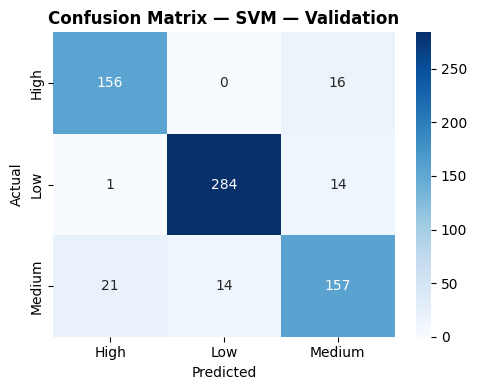


SVM — Test Results
  Macro F1 : 0.8995  |  AUC-ROC : 0.9847

              precision    recall  f1-score   support

        High       0.90      0.92      0.91       173
         Low       0.95      0.94      0.95       298
      Medium       0.84      0.84      0.84       192

    accuracy                           0.91       663
   macro avg       0.90      0.90      0.90       663
weighted avg       0.91      0.91      0.91       663



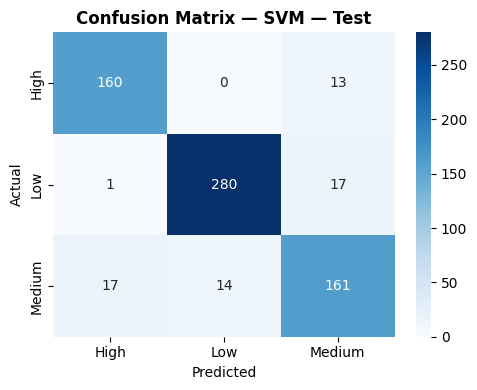

In [123]:
svm_best = svm_cv.best_estimator_
svm_val_f1,  svm_val_auc  = evaluate(svm_best, X_val,  y_val,  'SVM — Validation')
svm_test_f1, svm_test_auc = evaluate(svm_best, X_test, y_test, 'SVM — Test')


In [124]:
import joblib, os
joblib.dump(svm_best, "svm_model.pkl")
joblib.dump(mlb_tech, "mlb_tech.pkl")
...


Ellipsis

In [125]:
import joblib, os

# Save SVM model and all encoders needed by the Streamlit app
joblib.dump(svm_best,  "svm_model.pkl")
joblib.dump(mlb_tech,  "mlb_tech.pkl")
joblib.dump(mlb_prog,  "mlb_prog.pkl")
joblib.dump(mlb_soft,  "mlb_soft.pkl")
joblib.dump(le_y,      "le_y.pkl")
joblib.dump(le_cat,    "le_cat.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")
joblib.dump(float(df["normalized_salary"].median()), "salary_median.pkl")

print("Saved:")
for f in ["svm_model.pkl","mlb_tech.pkl","mlb_prog.pkl","mlb_soft.pkl","le_y.pkl","le_cat.pkl","feature_columns.pkl","salary_median.pkl"]:
    size = os.path.getsize(f) / 1024
    print(f"  {f}: {size:.1f} KB")


Saved:
  svm_model.pkl: 840.7 KB
  mlb_tech.pkl: 0.8 KB
  mlb_prog.pkl: 0.6 KB
  mlb_soft.pkl: 0.7 KB
  le_y.pkl: 0.4 KB
  le_cat.pkl: 0.6 KB
  feature_columns.pkl: 1.0 KB
  salary_median.pkl: 0.0 KB


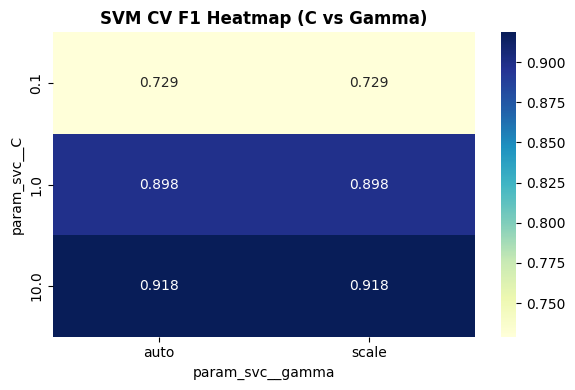

In [126]:
res_df = pd.DataFrame(svm_cv.cv_results_)
pivot  = res_df.pivot_table(values='mean_test_score',
                             index='param_svc__C', columns='param_svc__gamma')
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_title('SVM CV F1 Heatmap (C vs Gamma)', fontweight='bold')
plt.tight_layout()
plt.savefig('svm_cv_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [127]:
svm_f1_scores = []
for seed in SEEDS:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.15,
                                           random_state=seed, stratify=y)
    Xtr, _, ytr, _     = train_test_split(Xtr, ytr, test_size=0.15/0.85,
                                           random_state=seed, stratify=ytr)
    sm = SMOTE(random_state=seed)
    Xtr_sm, ytr_sm = sm.fit_resample(Xtr, ytr)
    svm = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(**{k.replace('svc__',''):v
                       for k,v in svm_cv.best_params_.items()},
                   kernel='rbf', probability=True, random_state=seed)),
    ])
    svm.fit(Xtr_sm, ytr_sm)
    score = f1_score(yte, svm.predict(Xte), average='macro')
    svm_f1_scores.append(score)
    print(f'  Seed {seed:>4}: F1 = {score:.4f}')

print(f'\nSVM Mean F1 = {np.mean(svm_f1_scores):.4f}  Std = {np.std(svm_f1_scores):.4f}')


  Seed   42: F1 = 0.8995
  Seed  123: F1 = 0.8984
  Seed  456: F1 = 0.9123
  Seed  789: F1 = 0.9043
  Seed 1024: F1 = 0.9001

SVM Mean F1 = 0.9029  Std = 0.0051


---
## 8. Model 3 — BERT (Fine-tuned Transformer)

Each job posting is converted to a structured natural-language sentence and fed into a pre-trained BERT model for sequence classification.


In [128]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (DistilBertTokenizer, DistilBertForSequenceClassification,
                           get_linear_schedule_with_warmup)

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
BERT_MODEL = 'distilbert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS     = 3

print(f'Device: {DEVICE}  |  Model: {BERT_MODEL}  |  MaxLen: {MAX_LEN}  |  Batch: {BATCH_SIZE}')


Device: cpu  |  Model: distilbert-base-uncased  |  MaxLen: 128  |  Batch: 32


In [129]:
def row_to_text(idx):
    row = df.iloc[idx]
    return (' | '.join([
        'Job: '          + str(row['job_category']),
        'Experience: '   + str(row['formatted_experience_level']),
        'Tech skills: '  + (', '.join(row['tech_skills'])  or 'none'),
        'Languages: '    + (', '.join(row['prog_langs'])   or 'none'),
        'Soft skills: '  + (', '.join(row['soft_skills'])  or 'none'),
        'Snippet: '      + str(row['description'])[:250],
    ]))

bert_texts = [row_to_text(i) for i in range(len(df))]
print('Sample BERT input:')
print(bert_texts[0][:300])


Sample BERT input:
Job: Software Developer | Experience: nan | Tech skills: none | Languages: none | Soft skills: none | Snippet: Education Bachelor's degree in software, math, or science required Job Skills Analytical skills, group work, knowledge of intended audience, understanding of different roles


In [130]:
class JobDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }


In [131]:
def train_bert(t_tr, y_tr, t_val, y_val, seed):
    torch.manual_seed(seed)
    tokenizer = DistilBertTokenizer.from_pretrained(BERT_MODEL)
    model     = DistilBertForSequenceClassification.from_pretrained(
                    BERT_MODEL, num_labels=3).to(DEVICE)

    tr_dl  = DataLoader(JobDataset(t_tr,  y_tr,  tokenizer, MAX_LEN),
                        batch_size=BATCH_SIZE, shuffle=True)
    val_dl = DataLoader(JobDataset(t_val, y_val, tokenizer, MAX_LEN),
                        batch_size=BATCH_SIZE)

    optimizer   = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    total_steps = len(tr_dl) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
                      optimizer,
                      num_warmup_steps=int(0.1 * total_steps),
                      num_training_steps=total_steps)

    best_f1, best_state, patience, wait = 0.0, None, 2, 0

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for batch in tr_dl:
            optimizer.zero_grad()
            out = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                labels=batch['labels'].to(DEVICE))
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += out.loss.item()

        model.eval()
        preds_v, true_v = [], []
        with torch.no_grad():
            for batch in val_dl:
                logits = model(
                    input_ids=batch['input_ids'].to(DEVICE),
                    attention_mask=batch['attention_mask'].to(DEVICE)).logits
                preds_v.extend(torch.argmax(logits, dim=1).cpu().numpy())
                true_v.extend(batch['labels'].numpy())

        val_f1 = f1_score(true_v, preds_v, average='macro')
        print(f'  Epoch {epoch+1}/{EPOCHS}  '
              f'loss={total_loss/len(tr_dl):.4f}  val_f1={val_f1:.4f}')

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print('  Early stopping.')
                break

    model.load_state_dict(best_state)
    return model, tokenizer


In [132]:
# Split index-based to keep text aligned with y
idx = np.arange(len(bert_texts))
idx_tv, idx_te = train_test_split(idx, test_size=0.15, random_state=SEED, stratify=y)
idx_tr, idx_vl = train_test_split(idx_tv, test_size=0.15/0.85,
                                   random_state=SEED, stratify=y[idx_tv])

t_tr  = [bert_texts[i] for i in idx_tr]
t_vl  = [bert_texts[i] for i in idx_vl]
t_te  = [bert_texts[i] for i in idx_te]
y_tr_b, y_vl_b, y_te_b = y[idx_tr], y[idx_vl], y[idx_te]

print(f'BERT  Train: {len(t_tr)}  Val: {len(t_vl)}  Test: {len(t_te)}')


BERT  Train: 3090  Val: 663  Test: 663


In [133]:
print(f'Training BERT (seed={SEED})...')
bert_model, tokenizer = train_bert(t_tr, y_tr_b, t_vl, y_vl_b, seed=SEED)

# Evaluate on test set
bert_model.eval()
test_dl = DataLoader(JobDataset(t_te, y_te_b, tokenizer, MAX_LEN),
                     batch_size=BATCH_SIZE)
preds_te, true_te, probs_te = [], [], []
with torch.no_grad():
    for batch in test_dl:
        logits = bert_model(input_ids=batch['input_ids'].to(DEVICE),
                            attention_mask=batch['attention_mask'].to(DEVICE)).logits
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds_te.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_te.extend(batch['labels'].numpy())
        probs_te.extend(probs)

probs_te    = np.array(probs_te)
bert_test_f1 = f1_score(true_te, preds_te, average='macro')
bert_test_auc = roc_auc_score(label_binarize(true_te, classes=[0,1,2]),
                               probs_te, multi_class='ovr', average='macro')

print(f'\nBERT Test F1  : {bert_test_f1:.4f}')
print(f'BERT Test AUC : {bert_test_auc:.4f}')
print()
print(classification_report(true_te, preds_te, target_names=le_y.classes_))


Training BERT (seed=42)...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7379.53it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  loss=0.8332  val_f1=0.7721
  Epoch 2/3  loss=0.2657  val_f1=0.8986
  Epoch 3/3  loss=0.1160  val_f1=0.9783

BERT Test F1  : 0.9807
BERT Test AUC : 0.9983

              precision    recall  f1-score   support

        High       0.97      0.98      0.97       173
         Low       1.00      1.00      1.00       298
      Medium       0.97      0.97      0.97       192

    accuracy                           0.98       663
   macro avg       0.98      0.98      0.98       663
weighted avg       0.98      0.98      0.98       663



In [134]:
bert_f1_scores = []
for seed in SEEDS:
    i_all = np.arange(len(bert_texts))
    i_tv, i_te = train_test_split(i_all, test_size=0.15,
                                   random_state=seed, stratify=y)
    i_tr, i_vl = train_test_split(i_tv,  test_size=0.15/0.85,
                                   random_state=seed, stratify=y[i_tv])

    btr  = [bert_texts[i] for i in i_tr]
    bvl  = [bert_texts[i] for i in i_vl]
    bte  = [bert_texts[i] for i in i_te]

    print(f'\n--- Seed {seed} ---')
    m, tok = train_bert(btr, y[i_tr], bvl, y[i_vl], seed=seed)
    m.eval()
    dl = DataLoader(JobDataset(bte, y[i_te], tok, MAX_LEN), batch_size=BATCH_SIZE)
    preds, true = [], []
    with torch.no_grad():
        for batch in dl:
            logits = m(input_ids=batch['input_ids'].to(DEVICE),
                       attention_mask=batch['attention_mask'].to(DEVICE)).logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            true.extend(batch['labels'].numpy())
    sc = f1_score(true, preds, average='macro')
    bert_f1_scores.append(sc)
    print(f'  -> F1 = {sc:.4f}')

print(f'\nBERT Mean F1 = {np.mean(bert_f1_scores):.4f}  Std = {np.std(bert_f1_scores):.4f}')



--- Seed 42 ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13297.94it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  loss=0.8332  val_f1=0.7721
  Epoch 2/3  loss=0.2657  val_f1=0.8986
  Epoch 3/3  loss=0.1160  val_f1=0.9783
  -> F1 = 0.9807

--- Seed 123 ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 14029.18it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  loss=0.7902  val_f1=0.7902
  Epoch 2/3  loss=0.2370  val_f1=0.9650
  Epoch 3/3  loss=0.1026  val_f1=0.9853
  -> F1 = 0.9655

--- Seed 456 ---


...

  Epoch 1/3  loss=0.7798  val_f1=0.8497
  Epoch 2/3  loss=0.2593  val_f1=0.9625
  Epoch 3/3  loss=0.1151  val_f1=0.9857
  -> F1 = 0.9792

--- Seed 789 ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13693.45it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  loss=0.8084  val_f1=0.7459
  Epoch 2/3  loss=0.2854  val_f1=0.9474
  Epoch 3/3  loss=0.1382  val_f1=0.9786
  -> F1 = 0.9744

--- Seed 1024 ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 14002.02it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  loss=0.8511  val_f1=0.7956
  Epoch 2/3  loss=0.2915  val_f1=0.9779
  Epoch 3/3  loss=0.1203  val_f1=0.9828
  -> F1 = 0.9756

BERT Mean F1 = 0.9751  Std = 0.0053


---
## 9. Model Comparison & Statistical Significance Testing


In [135]:
summary = pd.DataFrame({
    'Model':            ['Random Forest', 'SVM (RBF)', 'BERT'],
    'Test F1 (Macro)':  [rf_test_f1,  svm_test_f1,  bert_test_f1],
    'Test AUC-ROC':     [rf_test_auc, svm_test_auc, bert_test_auc],
    'Mean F1 (5 seeds)':[np.mean(rf_f1_scores),
                         np.mean(svm_f1_scores),
                         np.mean(bert_f1_scores)],
    'Std F1 (5 seeds)': [np.std(rf_f1_scores),
                         np.std(svm_f1_scores),
                         np.std(bert_f1_scores)],
}).set_index('Model')

print(summary.round(4).to_string())


               Test F1 (Macro)  Test AUC-ROC  Mean F1 (5 seeds)  Std F1 (5 seeds)
Model                                                                            
Random Forest           0.9533        0.9962             0.9541            0.0046
SVM (RBF)               0.8995        0.9847             0.9029            0.0051
BERT                    0.9807        0.9983             0.9751            0.0053


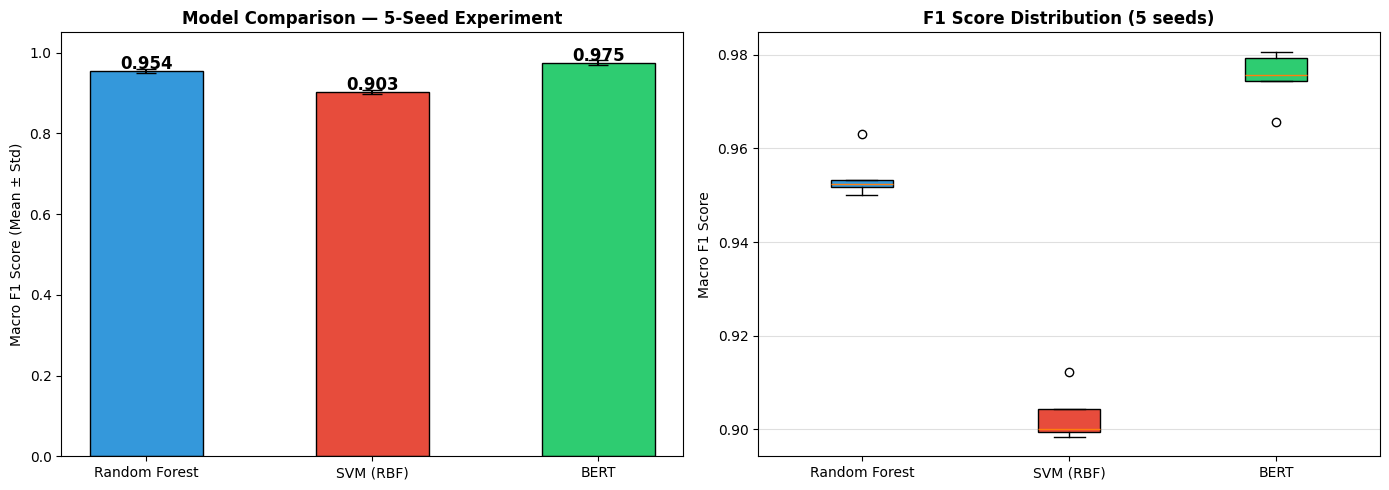

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = summary.index.tolist()
means  = summary['Mean F1 (5 seeds)'].values
stds   = summary['Std F1 (5 seeds)'].values
colors = ['#3498DB', '#E74C3C', '#2ECC71']

# Bar chart
bars = axes[0].bar(models, means, yerr=stds, capsize=7,
                   color=colors, edgecolor='black', width=0.5)
for bar, m in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{m:.3f}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Macro F1 Score (Mean ± Std)')
axes[0].set_title('Model Comparison — 5-Seed Experiment', fontweight='bold')

# Box plot
all_scores = [rf_f1_scores, svm_f1_scores, bert_f1_scores]
bp = axes[1].boxplot(all_scores, labels=models, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_ylabel('Macro F1 Score')
axes[1].set_title('F1 Score Distribution (5 seeds)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [137]:
pairs = [
    ('RF  vs SVM',  rf_f1_scores,  svm_f1_scores),
    ('RF  vs BERT', rf_f1_scores,  bert_f1_scores),
    ('SVM vs BERT', svm_f1_scores, bert_f1_scores),
]
print('Paired t-test (H0: no difference in mean F1):')
print(f'{"Pair":<15}  {"t-stat":>8}  {"p-value":>10}  {"Significant (p<0.05)":>22}')
print('-' * 62)
for name, a, b in pairs:
    t, p = stats.ttest_rel(a, b)
    sig  = 'YES' if p < 0.05 else 'NO'
    print(f'{name:<15}  {t:>8.3f}  {p:>10.4f}  {sig:>22}')


Paired t-test (H0: no difference in mean F1):
Pair               t-stat     p-value    Significant (p<0.05)
--------------------------------------------------------------
RF  vs SVM         40.975      0.0000                     YES
RF  vs BERT        -7.710      0.0015                     YES
SVM vs BERT       -26.423      0.0000                     YES


---
## 10. Learning Curves


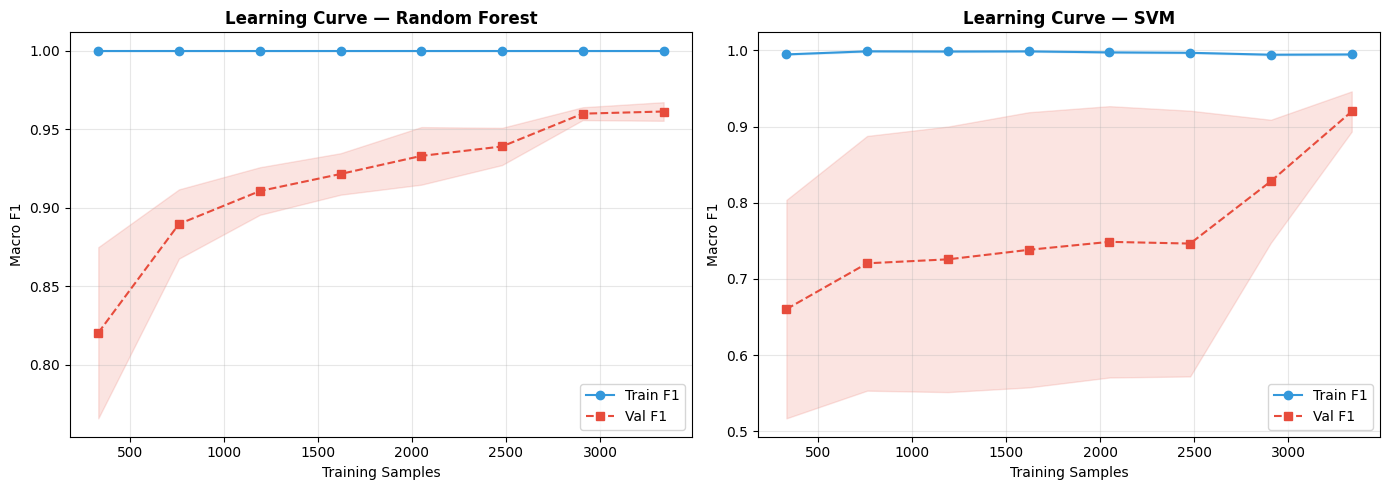

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [('Random Forest', rf_best), ('SVM', svm_best)]):
    sizes, tr_sc, val_sc = learning_curve(
        model, X_train_sm, y_train_sm,
        cv=5, scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

    ax.plot(sizes, tr_sc.mean(1),  'o-',  label='Train F1',  color='#3498DB')
    ax.fill_between(sizes, tr_sc.mean(1)-tr_sc.std(1),
                    tr_sc.mean(1)+tr_sc.std(1), alpha=0.15, color='#3498DB')
    ax.plot(sizes, val_sc.mean(1), 's--', label='Val F1',    color='#E74C3C')
    ax.fill_between(sizes, val_sc.mean(1)-val_sc.std(1),
                    val_sc.mean(1)+val_sc.std(1), alpha=0.15, color='#E74C3C')
    ax.set_title(f'Learning Curve — {name}', fontweight='bold')
    ax.set_xlabel('Training Samples'); ax.set_ylabel('Macro F1')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


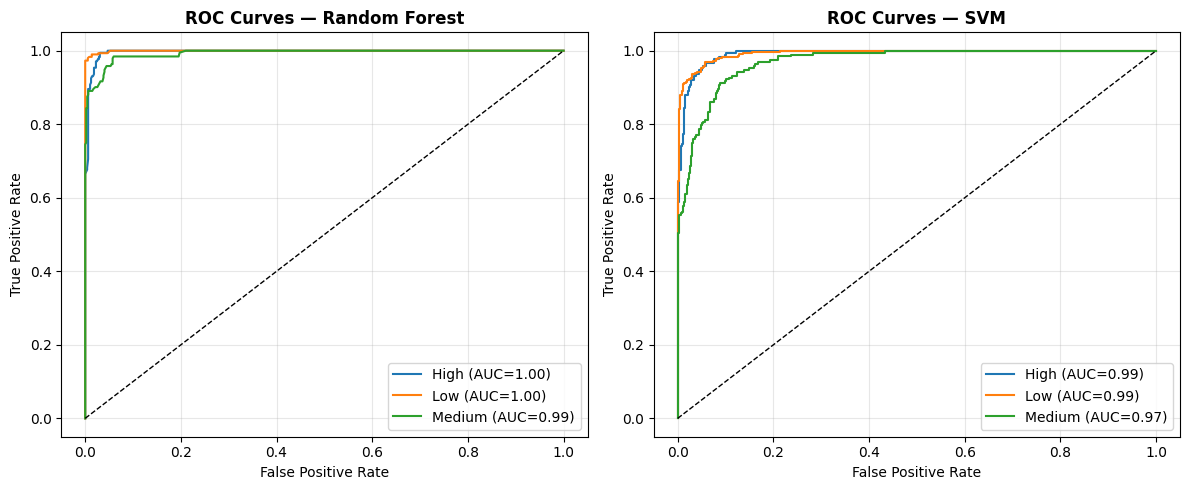

In [139]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])
fig, axes  = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, [('Random Forest', rf_best), ('SVM', svm_best)]):
    proba = model.predict_proba(X_test)
    for i, cls in enumerate(le_y.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        auc_val = roc_auc_score(y_test_bin[:, i], proba[:, i])
        ax.plot(fpr, tpr, label=f'{cls} (AUC={auc_val:.2f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(f'ROC Curves — {name}', fontweight='bold')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Conclusions



In [140]:
print('=' * 60)
print('    FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'  Dataset   : LinkedIn Job Postings (tech roles)')
print(f'  Samples   : {len(y)}')
print(f'  Features  : {X.shape[1]}')
print(f'  Split     : 70 / 15 / 15 (train / val / test)')
print()
for model, scores, tf1, tauc in [
    ('Random Forest', rf_f1_scores,   rf_test_f1,   rf_test_auc),
    ('SVM (RBF)',     svm_f1_scores,  svm_test_f1,  svm_test_auc),
    ('BERT',         bert_f1_scores, bert_test_f1, bert_test_auc),
]:
    print(f'  {model:<15}  Test F1={tf1:.4f}  AUC={tauc:.4f}  '
          f'Mean±Std={np.mean(scores):.4f}±{np.std(scores):.4f}')
print('=' * 60)


    FINAL RESULTS SUMMARY
  Dataset   : LinkedIn Job Postings (tech roles)
  Samples   : 4416
  Features  : 58
  Split     : 70 / 15 / 15 (train / val / test)

  Random Forest    Test F1=0.9533  AUC=0.9962  Mean±Std=0.9541±0.0046
  SVM (RBF)        Test F1=0.8995  AUC=0.9847  Mean±Std=0.9029±0.0051
  BERT             Test F1=0.9807  AUC=0.9983  Mean±Std=0.9751±0.0053
